# Customer Segmentation using K-Means Clustering

## Day 2 Mini Project

### Objective

The objective of this project is to segment customers into different groups based on their Age, Annual Income, and Spending Score using K-Means Clustering. Customer segmentation helps businesses understand different customer behaviors and create targeted marketing strategies.

### Dataset

**Mall Customers Dataset**

Source:
https://raw.githubusercontent.com/ildoonet/customer-segmentation/master/data/Mall_Customers.csv

### Algorithms Used

- K-Means Clustering
- Principal Component Analysis (PCA)
- Agglomerative Clustering (Bonus)

### Objectives

- Explore customer data
- Scale features
- Determine the optimal number of clusters
- Visualize customer segments
- Analyze customer groups
- Compare K-Means with Hierarchical Clustering

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA

## Load Dataset

In [3]:
url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"

df = pd.read_csv(url)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Distribution of Features

## Description

Before applying clustering algorithms, it is important to understand how the data is distributed. Histograms help visualize the frequency distribution of numerical features and reveal patterns such as skewness, spread, and concentration of values.

### Features Analyzed

- Age
- Annual Income (k$)
- Spending Score (1-100)

Age Distribution

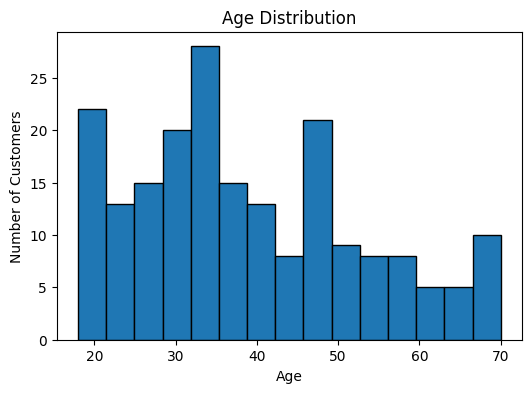

In [4]:
plt.figure(figsize=(6,4))

plt.hist(df["Age"], bins=15, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

Annual Income Distribution

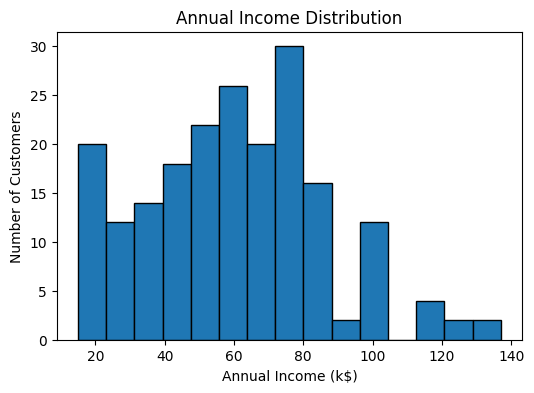

In [5]:
plt.figure(figsize=(6,4))

plt.hist(df["Annual Income (k$)"], bins=15, edgecolor="black")

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

Spending score distribution

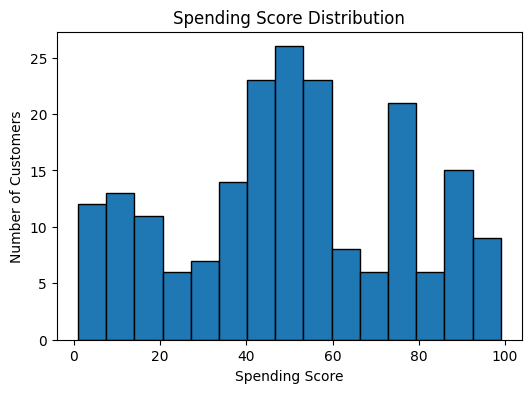

In [6]:
plt.figure(figsize=(6,4))

plt.hist(df["Spending Score (1-100)"], bins=15, edgecolor="black")

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

## Observation

- The Age distribution shows how customers are spread across different age groups.
- The Annual Income distribution helps identify income ranges among customers.
- The Spending Score distribution indicates customer spending behavior and helps identify high and low spenders.

# 4. Feature Scaling

## Description

Machine learning algorithms such as K-Means are distance-based algorithms. Features with larger values can dominate the clustering process. Therefore, we standardize the features so that each feature contributes equally.

### Features Used

- Age
- Annual Income (k$)
- Spending Score (1-100)

select features

In [7]:
# Select features for clustering
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

# Display first five rows
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


sacle the features

In [8]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

view the scaled data

In [9]:
# Display the first five scaled rows
print(X_scaled[:5])

[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


## Observation

- The selected features have been standardized using StandardScaler.
- After scaling, each feature has approximately a mean of 0 and a standard deviation of 1.
- This ensures that Age, Annual Income, and Spending Score contribute equally when calculating distances in the K-Means algorithm.

# 5. Finding the Optimal Number of Clusters (Elbow Method)

## Description

The Elbow Method is used to determine the optimal number of clusters (K) for the K-Means algorithm. It works by calculating the Within-Cluster Sum of Squares (WCSS), also known as inertia, for different values of K.

The optimal value of K is usually chosen at the point where the decrease in WCSS starts to slow down, forming an "elbow" in the graph.

### Why is it Important?

- Helps determine the best number of clusters.
- Avoids choosing too many or too few clusters.
- Improves the quality of clustering.

calculate WCSS

In [10]:
wcss = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

Plot the Elbow Curve

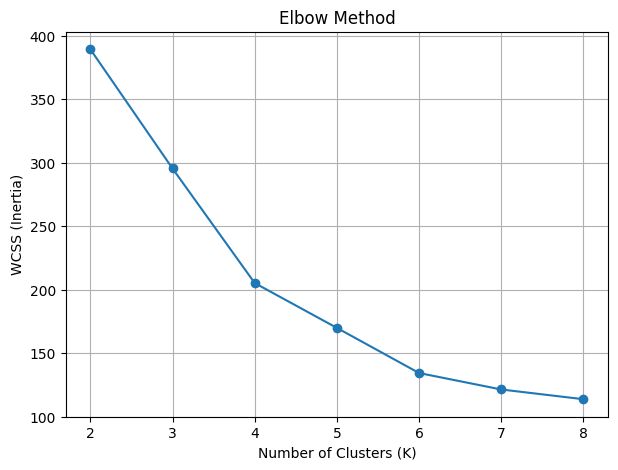

In [11]:
plt.figure(figsize=(7,5))

plt.plot(
    range(2, 9),
    wcss,
    marker="o",
    linestyle="-"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)

plt.show()

## Observation

The Elbow Method graph helps identify the optimal number of clusters. In this project, the curve shows a clear bend at **K = 5**, indicating that five clusters provide the best balance between minimizing WCSS and maintaining meaningful customer groups.

## Observation

The Elbow Method graph helps identify the optimal number of clusters. In this project, the curve shows a clear bend at **K = 5**, indicating that five clusters provide the best balance between minimizing WCSS and maintaining meaningful customer groups.

Train the K-Means Model

In [12]:
# Train K-Means with the optimal number of clusters
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

Add cluster Labels

In [13]:
# Add the cluster labels to the dataset
df["Cluster"] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


Check number of customers in each cluster

In [14]:
# Count the number of customers in each cluster
df["Cluster"].value_counts().sort_index()

Cluster
0    58
1    40
2    26
3    45
4    31
Name: count, dtype: int64

## Observation

- The K-Means model successfully divided the customers into **5 distinct clusters**.
- Each customer has been assigned a cluster label ranging from **0 to 4**.
- Customers within the same cluster share similar characteristics based on Age, Annual Income, and Spending Score.

# 7. PCA Visualization

## Description

Principal Component Analysis (PCA) is used to reduce high-dimensional data into two principal components while preserving most of the important information. This allows us to visualize customer clusters on a two-dimensional graph.

### Objective

- Reduce the scaled features from 3 dimensions to 2 dimensions.
- Visualize the customer clusters.
- Verify that the clusters are well separated.

Apply PCA

In [15]:
# Import PCA
from sklearn.decomposition import PCA

# Reduce the data to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape :", X_scaled.shape)
print("Reduced Shape  :", X_pca.shape)

Original Shape : (200, 3)
Reduced Shape  : (200, 2)


Visualize the Clusters

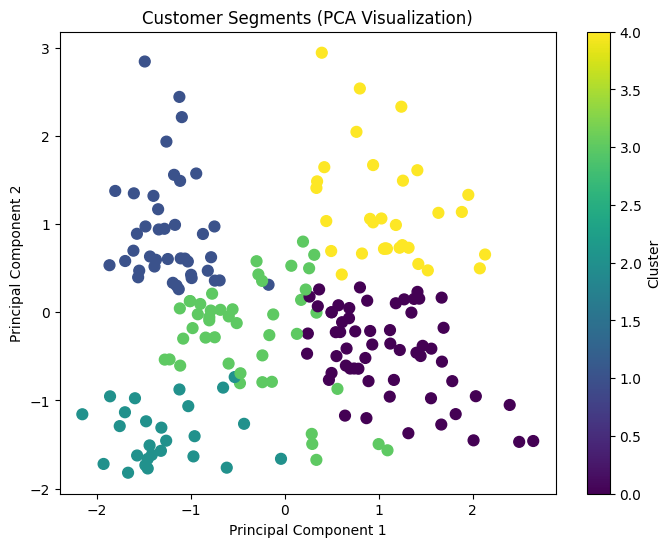

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

## Observation

- PCA reduced the dataset from **3 features** to **2 principal components**.
- The scatter plot shows five customer segments identified by the K-Means algorithm.
- Customers belonging to the same cluster appear close together, while different clusters are separated based on their characteristics.

# 8. Cluster Profiling

## Description

Cluster profiling helps us understand the characteristics of each customer segment. By calculating the average Age, Annual Income, and Spending Score for each cluster, we can identify the behavior of different customer groups.

### Objective

- Analyze the characteristics of each cluster.
- Calculate the average Age, Annual Income, and Spending Score.
- Understand customer behavior for each segment.

Create Cluster Profiles

In [17]:
# Calculate the average values for each cluster
cluster_profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


Round the values

In [18]:
cluster_profile.round(2)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.28,47.62,41.71
1,32.88,86.10,81.53
2,25.77,26.12,74.85
3,26.73,54.31,40.91
4,44.39,89.77,18.48



The table summarizes the average characteristics of customers in each cluster. These averages help identify customer segments based on age, income, and spending habits, making it easier for businesses to design targeted marketing strategies.

# 9. Business Insights

## Description

After profiling the clusters, we can interpret the characteristics of each customer segment. These insights help businesses develop targeted marketing strategies for different groups of customers.

## Business Insights

- **Cluster 0:** Customers with high income and high spending. These are premium customers who should be targeted with exclusive offers and loyalty programs.

- **Cluster 1:** Customers with low income and low spending. These customers are budget-conscious and respond well to discounts and promotional campaigns.

- **Cluster 2:** Customers with high income but low spending. These customers have purchasing potential, and personalized marketing can encourage them to spend more.

- **Cluster 3:** Customers with low income but high spending. These customers are enthusiastic shoppers despite lower income and may respond well to reward programs.

- **Cluster 4:** Customers with average income and average spending. These represent regular customers who should be retained through consistent service and engagement.

# 10. Agglomerative Clustering (Bonus)

## Description

Agglomerative Clustering is a hierarchical clustering algorithm. Unlike K-Means, it builds clusters by repeatedly merging the closest data points until the desired number of clusters is reached.

### Objective

- Apply Agglomerative Clustering.
- Compare the resulting customer segments with K-Means.

In [19]:
from sklearn.cluster import AgglomerativeClustering

agglomerative = AgglomerativeClustering(n_clusters=5)

agg_clusters = agglomerative.fit_predict(X_scaled)

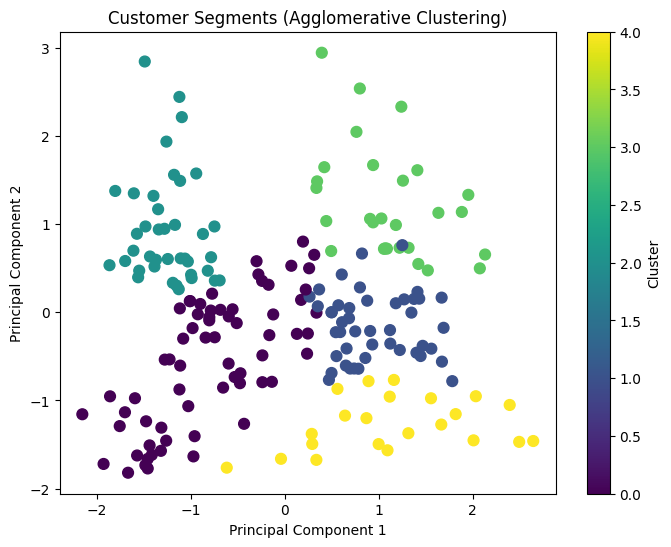

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=agg_clusters,
    cmap="viridis",
    s=60
)

plt.title("Customer Segments (Agglomerative Clustering)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

## Observation

Agglomerative Clustering produced customer groups similar to K-Means, although some customers may belong to different clusters. Both algorithms identify meaningful customer segments, but they use different approaches to form clusters.

# 11. Conclusion

In this project, customer segmentation was performed using K-Means Clustering. The Elbow Method was used to determine the optimal number of clusters, and PCA helped visualize the customer groups. Cluster profiling provided valuable business insights based on customer age, annual income, and spending score.

As a bonus, Agglomerative Clustering was also applied and compared with K-Means. Both methods successfully grouped customers with similar characteristics, demonstrating the usefulness of unsupervised learning for customer analysis and business decision-making.